In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

In [5]:
data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)
x_o = data_norm[:, :, 28:29].squeeze()
S_o = S0[:, :, 28:29].squeeze()

/tmp/ipykernel_2405335/1490183152.py:12: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_2405335/1490183152.py:12: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


In [6]:
data_norm_flat = data_norm.reshape(-1, data_norm.shape[-1])
data_norm_flat_in_brain = data_norm_flat[brain_mask.astype(np.bool).reshape(-1),:]

In [7]:
idx = np.argsort(bvals)

In [9]:
std = data_norm[...,b0_mask].std(-1)
m = data_norm[...,b0_mask].mean(-1)

In [10]:
std_flat = std.reshape(-1,1)
std_flat_in_brain = std_flat[brain_mask.astype(np.bool).reshape(-1)]
mean_flat_in_brain = m.reshape(-1,1)[brain_mask.astype(np.bool).reshape(-1)]

In [11]:
mean_flat_in_brain.mean()

np.float32(0.9991705)

In [16]:
1/np.quantile(std_flat_in_brain, [0.05,0.5, 0.95])

array([115.81562235,  43.98490881,   5.85125159])

<OrthoSlicer3D: (104, 104, 72)>

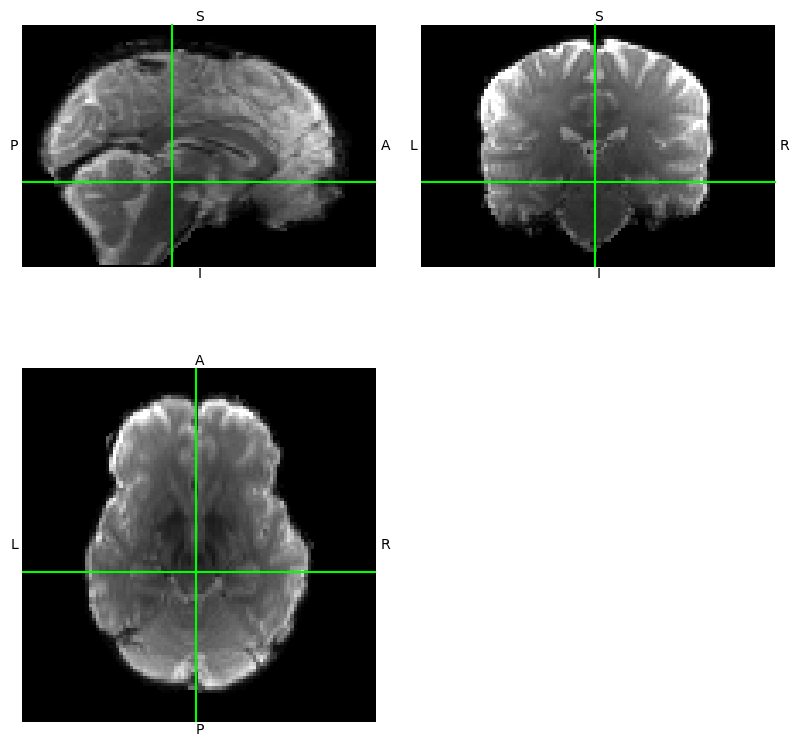

In [17]:
%matplotlib inline
import nibabel as nb
nb.Nifti1Image(S0, affine).orthoview()

In [18]:
import numpy as np

import jax
import jax.numpy as jnp

from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx


In [81]:
from dmri.train.utils import load_cfg, load_checkpoint

checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/full_ball3stick_simformer6")

In [85]:
graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, static, state)
model.eval()

In [86]:
p_mask,masks, theta, x_o, acq, score = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

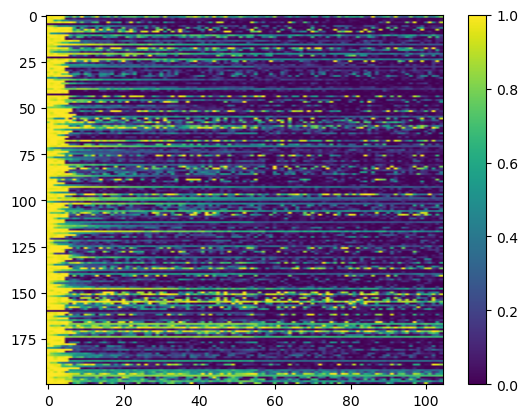

: 

In [ ]:
import matplotlib.pyplot as plt

p_mask,masks, theta, x_os, acq, score = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [71]:
#idx = 2
idx = 22
masks[idx]

Array([False,  True,  True,  True,  True], dtype=bool)

In [72]:
acq.bvals[idx]

Array([   0.,    0.,    0.,    0.,    0.,    0., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 2000., 2000., 2000., 2000., 2000., 2000., 2000.,
       2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000.,
       2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000.,
       2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000.,
       2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000., 2000.,
       2000., 2000., 2000., 2000., 2000., 2000.], dtype=float32)

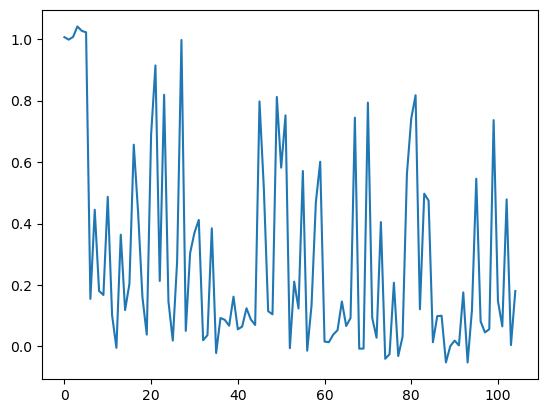

In [73]:
plt.plot(x_os[idx])

In [74]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.1]))

In [75]:
mask_true= masks[idx]

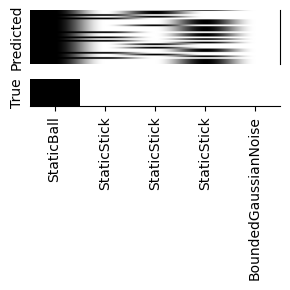

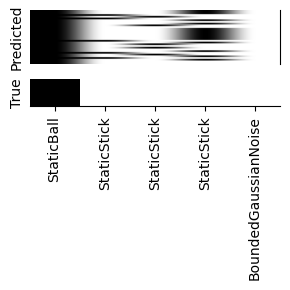

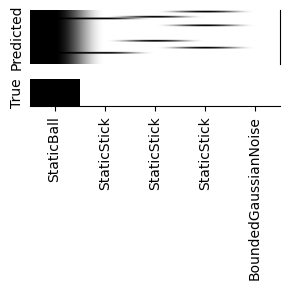

In [76]:
import matplotlib.pyplot as plt

for t in [0.1, 0.5, 0.9]:
    mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 32), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([t]))
    fig = plt.figure(figsize=(3, 3))

    # Create a grid with 90% height for the predicted mask and 10% height for the true mask
    grid = plt.GridSpec(2, 1, height_ratios=[4, 2])

    # Plot predicted mask on top subplot
    ax1 = plt.subplot(grid[0])
    ax1.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax1.set_ylabel('Predicted')
    ax1.set_xticks([])  # Hide x-ticks
    ax1.set_yticks([])  # Hide y-ticks
    # Remove unnecessary spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)

    # Plot true mask on bottom subplot
    ax2 = plt.subplot(grid[1])
    ax2.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax2.set_ylabel('True')
    #ax2.set_xlabel('Model Type')

    # Set x-tick labels
    model_labels = [str(m).split(".")[-1].split("'")[0] for m in sim_type.model_types] + [str(m).split(".")[-1].split("'")[0] for m in sim_type.noise_types]
    ax2.set_xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)))
    ax2.set_xticklabels(model_labels, rotation=90)

    # Remove y-axis ticks
    ax2.set_yticks([])
    # Remove unnecessary spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.svg")
    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.png")

In [77]:
from functools import partial

thetas_post = jax.vmap(partial(model.sample_theta, num_steps=512, max_noise=80, sample_method="ode"), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

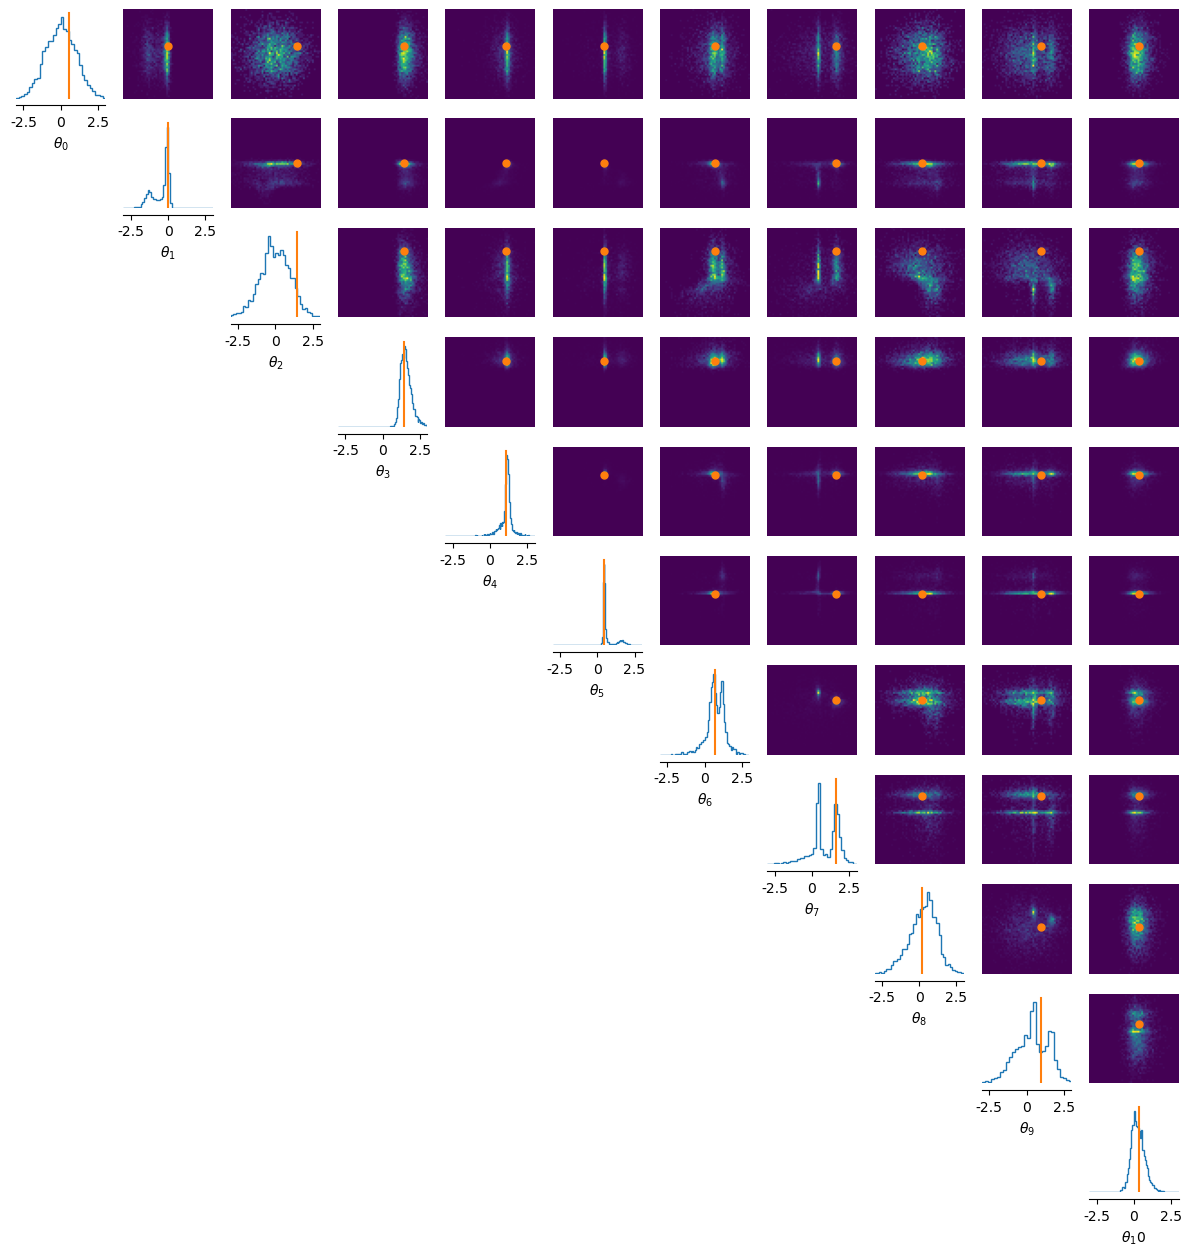

In [78]:
import sbi
from sbi.analysis.plot import pairplot

fig,axes = pairplot(thetas_post, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(15, 15))
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.svg")
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.png")

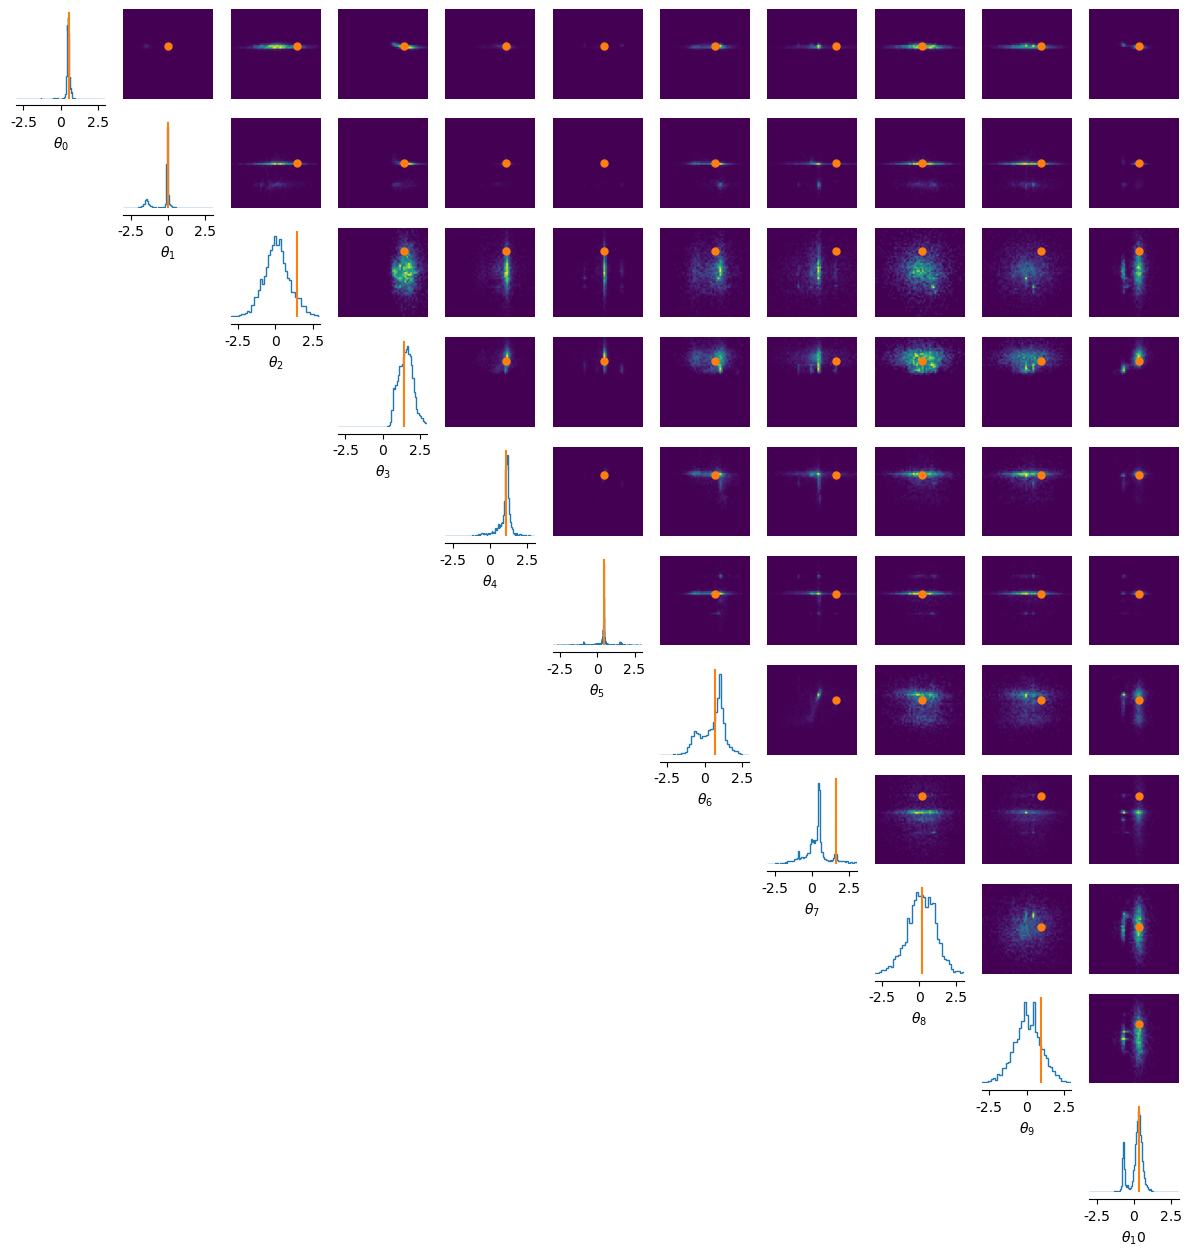

In [155]:
fig,axes = pairplot(theta_mcmc_corrected2, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(15, 15))

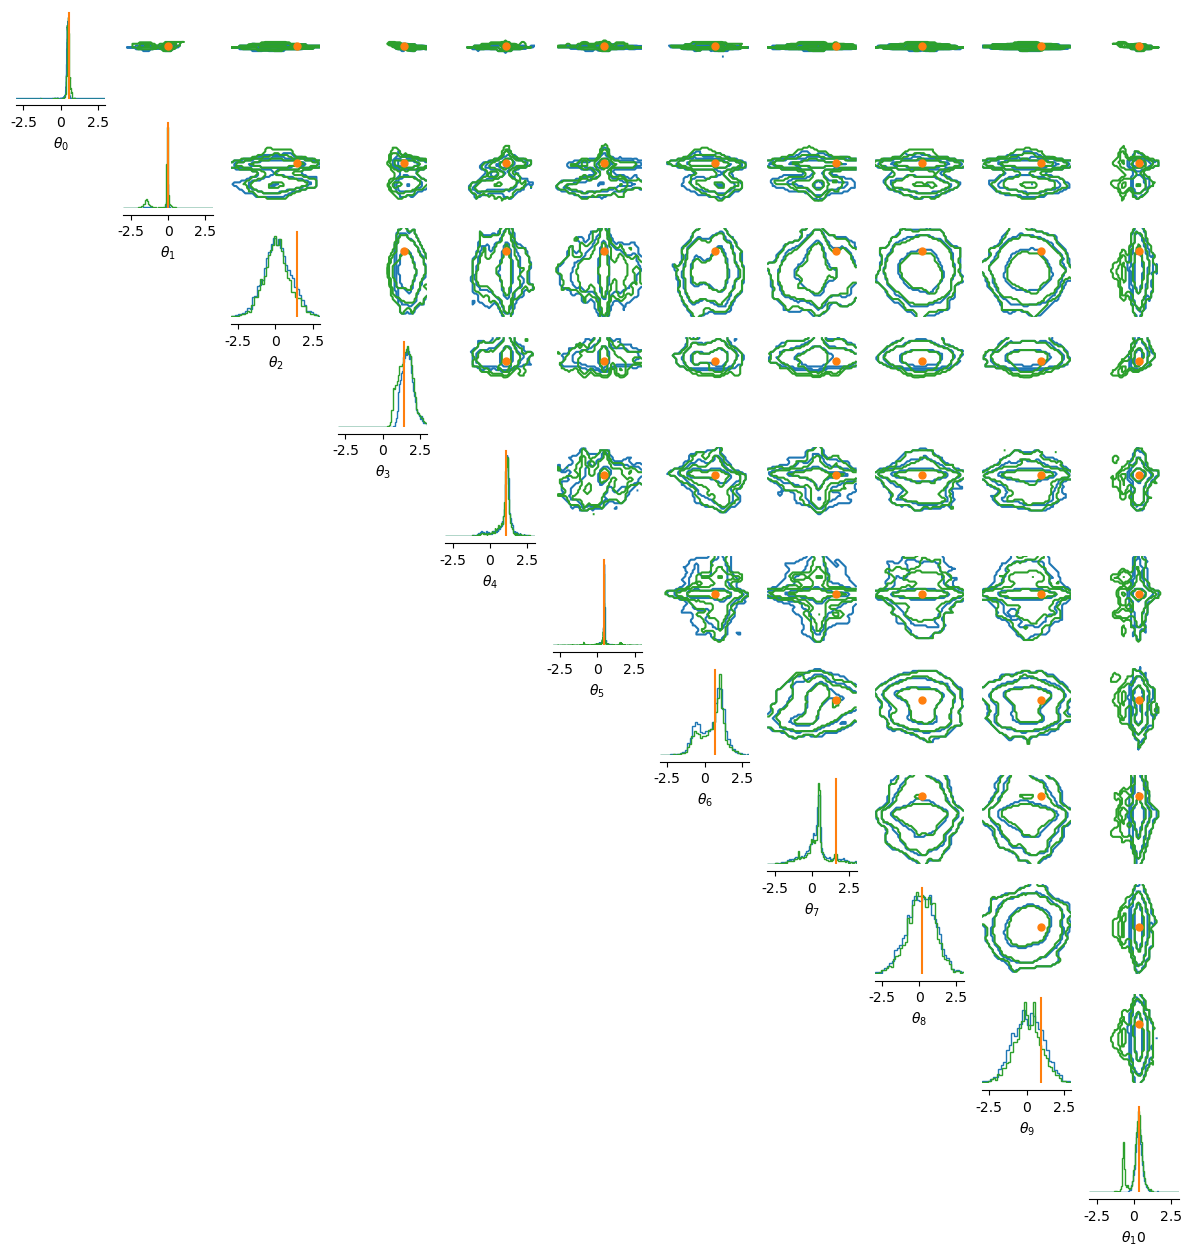

In [156]:
fig,axes = pairplot([thetas_post,theta_mcmc_corrected2], points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], upper="contour",figsize=(15, 15))

In [51]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [52]:
ll = loglikelihood(theta[idx])

In [53]:
ll

Array(231.163, dtype=float32)

Text(0, 0.5, 'MRI Signal')

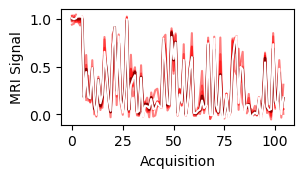

In [54]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(3, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [55]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=80, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [56]:
def log_potential(theta):
    return log_posterior(theta, masks[idx], acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])

In [57]:
from blackjax import mala, hmc

kernel =hmc(log_potential, 1e-2, inverse_mass_matrix=jnp.ones(11), num_integration_steps=10)

In [151]:
# from blackjax import rmh

# kernel = rmh(log_potential, lambda rng, x: x + 0.01*jax.random.normal(rng, x.shape))

In [58]:
@jax.jit
def mcmc(theta, rng):
    state = kernel.init(theta)

    def step(state, rng):
        new_state, info = kernel.step(rng, state)
        return new_state, None

    return jax.lax.scan(step, state, jax.random.split(rng, 50))[0].position


In [153]:
theta_mcmc_corrected = jax.vmap(mcmc, in_axes=(0,0))(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [154]:
theta_mcmc_corrected2 = jax.vmap(mcmc, in_axes=(0,0))(theta_mcmc_corrected, jax.random.split(jax.random.key(0), 4096))

In [53]:
effectve_sample_size(thetas_post)

Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


Array(8.376, dtype=float32)

In [41]:
effectve_sample_size(thetas_post)

Array(1.057, dtype=float32)

In [27]:
data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)


data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
S0 = np.where(brain_mask, S0, 0.)
x_o = data_norm[:, :, 28:29].squeeze()
S_o = S0[:, :, 28:29].squeeze()


/tmp/ipykernel_2491785/295385722.py:13: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_2491785/295385722.py:13: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


In [28]:
idx = np.argsort(bvals)
bvals = bvals[idx]
bvecs = bvecs[idx]
x_o = x_o[...,idx]
data_norm = data_norm[...,idx]


In [29]:
np.quantile(x_o, [0.01, 0.999])

array([0.   , 1.382])

In [30]:
x_o.shape

(104, 104, 105)

In [31]:
x_o = jnp.clip(x_o, None, 1.4)

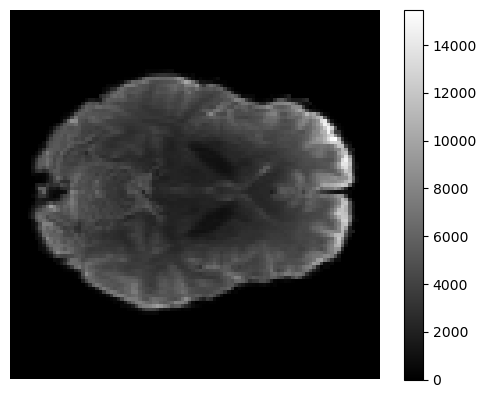

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
l = ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
plt.colorbar(l)
#ax.set_title('HCP coronal slice B0 with ROI')

In [33]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

In [34]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

In [35]:
full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [36]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])
brain_mask_slice = brain_mask[:,:,28:29].squeeze()
brain_mask_slice_flat = brain_mask_slice.reshape(-1)

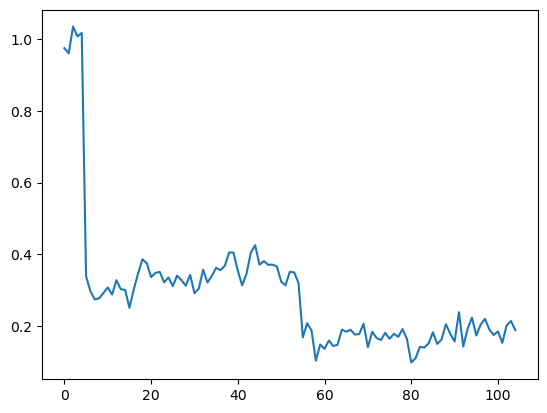

In [37]:
plt.plot(x_o_flat[5000])

In [172]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

In [236]:



@jax.jit
def mcmc(rng,theta, mask, acq, x):
    log_potential = partial(log_posterior, mask=mask, acq=acq, x=x)
    kernel = hmc(log_potential, 1e-2, jnp.ones(11), 10)
    state = kernel.init(theta)

    def step(state, rng):
        new_state, info = kernel.step(rng, state)
        jax.debug.print("{a}", a=info.acceptance_rate)
        return new_state, None

    return jax.lax.scan(step, state, jax.random.split(rng, 100))[0].position

# @jax.jit
# def importance_resample(key,x, K=20):
#     key, subkey = jax.random.split(key)
#     key_propose = jax.random.split(subkey, K)
#     samples, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=32, max_noise=40), in_axes=(0,None,None, None, None))(key_propose, acq.bvals, acq.bvecs, x,model_mask)
#     log_probs_posterior = jax.vmap(log_posterior, in_axes=(0,None,None,None))(samples, model_mask, acq, x)
#     weights = log_probs_posterior - log_probs
#     weights = jax.nn.softmax(weights)
#     weights = jnp.nan_to_num(weights, 0)
#     sample = jax.random.choice(subkey, samples, p=weights)
#     ess = 1/jnp.sum(weights**2)
#     ess = jnp.nan_to_num(ess, 0, posinf=0,neginf=0)
#     return sample, ess




def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    propose_fn = partial(model.sample_theta, num_steps=64, max_noise=20)
    theta = propose_fn(key, acq.bvals, acq.bvecs, x,model_mask)
    theta_mcmc_corrected = mcmc(subkey, theta, model_mask, acq, x)
    return theta_mcmc_corrected



sample_theta_per_x =jax.jit(jax.vmap(sample_mcmc_correct))

In [194]:
thetas = [sample_theta_per_x(jax.random.split(jax.random.key(0),x_o_flat.shape[0]), x_o_flat) for i in range(2)]

Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


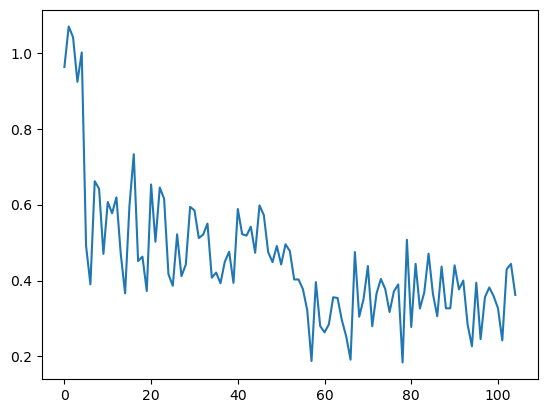

In [227]:
plt.plot(x_o_flat[4420])

In [202]:
fractions = sum([jax.vmap(to_fractions)(theta) for theta in thetas])/3

In [203]:
fractions

Array([[0.663, 0.003, 0.   , 0.   ],
       [0.667, 0.   , 0.   , 0.   ],
       [0.667, 0.   , 0.   , 0.   ],
       ...,
       [0.667, 0.   , 0.   , 0.   ],
       [0.667, 0.   , 0.   , 0.   ],
       [0.667, 0.   , 0.   , 0.   ]], dtype=float32)

In [204]:
fractions[...,0].mean()

Array(0.587, dtype=float32)

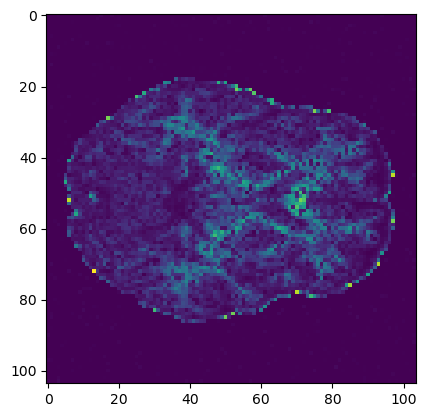

In [206]:
plt.imshow(fractions[...,1].reshape(x_o.shape[:2]))

In [240]:
theta = sample_mcmc_correct(jax.random.key(2), x_o_flat[4420])

[ True  True  True]
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
[ True  True  True]
1.0
1.0
1.0
1.0
0.9718915224075317
1.0
0.8723220229148865
1.0
0.8137761354446411
1.0
0.9907126426696777
1.0
0.9825829267501831
1.0
1.0
0.6601734161376953
0.9898664951324463
0.9224458336830139
1.0
1.0
0.9829203486442566
0.8860860466957092
1.0
1.0
0.8985716104507446
1.0
1.0
0.9950531721115112
0.9679400324821472
1.0
0.9864286780357361
1.0
0.9885004758834839
1.0
0.893812894821167
1.0
0.9789613485336304
0.9801645874977112
1.0
1.0
0.9713430404663086
0.88164222240448
1.0
0.9989324808120728
0.9975768327713013
0.9691296815872192
0.9739253520965576
0.9857289791107178
1.0
1.0
0.963725209236145
0.9965802431106567
0.9914082884788513
0.9206809997558594
1.0
1.0
0.9858493804931641
0.9933843612670898
0.9883949160575867
1.0
0.7315207719802856
1.0
1.0
0.9079298973083496
1.0
0.930730938911438
0.979835569858551
0.

In [239]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

#theta = thetas[0]
theta = theta[None]
x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0),theta.shape[0]),theta)
i = 4420
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

ValueError: Sizes passed to split must be nonnegative, got [np.int64(3), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(-9)]

In [242]:
x_o_flat.sum()

Array(192640.72, dtype=float32)

In [243]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)
#sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 50_000
key = jax.random.key(0)
for i in range(5):
    thetas_full = []
    key, subkey = jax.random.split(key)
    for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
        print("Batch", batch_start)
        subkey, subkey_ = jax.random.split(subkey)
        batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
        batch_data = full_data_flat_in_brain[batch_start:batch_end]
        batch_keys = jax.random.split(subkey_, batch_data.shape[0])
        #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
        batch_thetas = sample_theta_per_x(batch_keys, batch_data)
        batch_thetas = np.array(batch_thetas)
        thetas_full.append(batch_thetas)
        #print(ess.mean())
    thetas_full = np.concatenate(thetas_full, axis=0)

    thetas.append(thetas_full)


Batch 0
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


2025-05-06 10:48:10.336034: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_sample_mcmc_correct] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


: 

In [385]:
len(thetas),len(thetas_full)

(5, 227840)

In [444]:
# # Convert list of arrays to a single array first
# thetas_array = np.array(thetas)
# np.save("thetas.npy", thetas_array)

In [92]:
# thetas_old = np.load("thetas.npy")

In [351]:
thetas = []
for i in range(50):
    try:
        theta_i = np.load(f"thetas_{i}.npy")
        #theta_i[np.isnan(theta_i)] = thetas_old[i][np.isnan(theta_i)]
        theta_i[np.isnan(theta_i)] = np.random.randn(*theta_i[np.isnan(theta_i)].shape)
        thetas.append(theta_i)
    except:
        print(f"thetas_{i}.npy does not exist")


In [352]:
len(thetas)

50

In [353]:
import jax
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)
def to_fractions(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_fractions

def to_diffusivities(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[0].lam

def direction_s1(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[1].mu

def direction_s2(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[2].mu

def direction_s3(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[3].mu

fractions = []
for theta in thetas:
    fractions += [jax.vmap(to_fractions)(theta)]

diffusivities = []
for theta in thetas:
    diffusivities += [jax.vmap(to_diffusivities)(theta)]

mu_s1 = []
for theta in thetas:
    mu_s1 += [jax.vmap(direction_s1)(theta)]

mu_s2 = []
for theta in thetas:
    mu_s2 += [jax.vmap(direction_s2)(theta)]

mu_s3 = []
for theta in thetas:
    mu_s3 += [jax.vmap(direction_s3)(theta)]

fractions = np.array(fractions)
fractions_mean = fractions.mean(axis=0)
fractions_std = fractions.std(axis=0)


In [354]:
diffusivities = np.array(diffusivities)
diffusivities_mean = diffusivities.mean(axis=0)
diffusivities_std = diffusivities.std(axis=0)


In [355]:
full_fractions_mean = np.zeros(full_data_flat.shape[:-1] + (4,))
full_fractions_std = np.zeros(full_data_flat.shape[:-1] + (4,))
full_fractions_mean[brain_mask_flat.astype(np.bool),:] = fractions_mean
full_fractions_std[brain_mask_flat.astype(np.bool),:] = fractions_std
full_fractions_mean = full_fractions_mean.reshape(data_norm.shape[:-1] + (4,))
full_fractions_std = full_fractions_std.reshape(data_norm.shape[:-1] + (4,))


In [356]:
full_diffusivities_mean = np.zeros(full_data_flat.shape[:-1] + (1,))
full_diffusivities_std = np.zeros(full_data_flat.shape[:-1] + (1,))
full_diffusivities_mean[brain_mask_flat.astype(np.bool),:] = diffusivities_mean[...,None]
full_diffusivities_std[brain_mask_flat.astype(np.bool),:] = diffusivities_std[...,None]
full_diffusivities_mean = full_diffusivities_mean.reshape(data_norm.shape[:-1] + (1,))
full_diffusivities_std = full_diffusivities_std.reshape(data_norm.shape[:-1] + (1,))


In [357]:
full_fractions_mean.shape

(104, 104, 72, 4)

In [358]:
mu_s1 = np.array(mu_s1)
mu_s2 = np.array(mu_s2)
mu_s3 = np.array(mu_s3)


In [363]:
def pred_signal(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=None)

def pred_ll(theta, x):
    return sim_type.from_theta(theta, model_mask=model_mask).log_likelihood(acq, x) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()


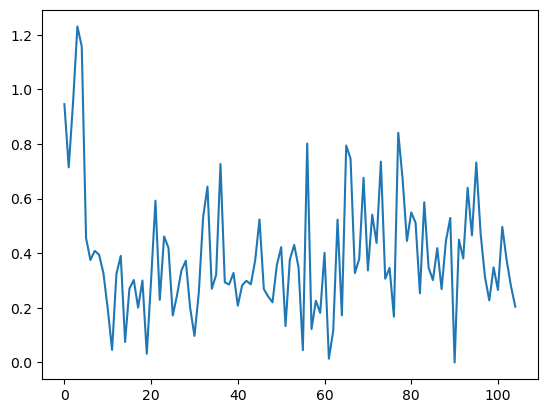

In [364]:
plt.plot(full_data_flat_in_brain[0])

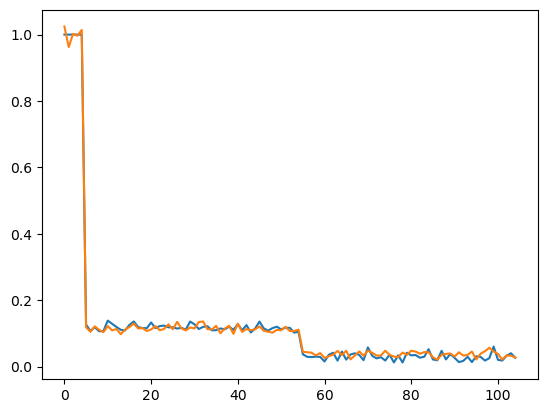

In [366]:
plt.plot(pred_signal(thetas[11][10600]))
plt.plot(full_data_flat_in_brain[10600])

In [367]:

weights =jax.vmap(pred_ll, in_axes=(0,None))(jnp.stack([t[10520] for t in thetas]), full_data_flat_in_brain[10520])

In [368]:
jax.nn.softmax(weights)

Array([0.   , 0.   , 0.   , 0.   , 0.   , 0.722, 0.001, 0.   , 0.   ,
       0.   , 0.   , 0.03 , 0.   , 0.   , 0.   , 0.   , 0.075, 0.006,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.019, 0.   , 0.041,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.003, 0.069, 0.002, 0.   , 0.   , 0.018, 0.   ,
       0.   , 0.   , 0.   , 0.015, 0.001], dtype=float32)

In [369]:
import numpy as np
from sklearn.decomposition import PCA


def sph2cart(angles):
    theta, phi = angles[..., 0], angles[..., 1]
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.stack([x, y, z], axis=-1)

def reorder_angles_for_consistency(angles1, angles2, angles3, n_references=1):
    """
    Reorder fiber directions across the batch so that similar directions are consistently aligned
    for meaningful averaging using PCA to determine multiple global reference directions.

    Args:
        angles1: [N, 2] array of [theta, phi] directions
        angles2: [N, 2] array of [theta, phi] directions
        angles3: [N, 2] array of [theta, phi] directions
        n_references: Number of PCA components to use as global references

    Returns:
        reordered_angles1: [N, 2] aligned to the dominant global direction(s)
        reordered_angles2: [N, 2] second-best aligned direction(s)
        reordered_angles3: [N, 2] least aligned direction(s)
    """


    v1 = sph2cart(angles1)
    v2 = sph2cart(angles2)
    v3 = sph2cart(angles3)

    # Convert nan to random vector


    # === Step 1: Use PCA of all vectors to get global references ===
    all_vectors = np.vstack([v1, v2, v3])
    # Covert nan to 0
    all_vectors[np.isnan(all_vectors)] = np.random.randn(*all_vectors[np.isnan(all_vectors)].shape)*0.01
    pca = PCA(n_components=n_references)
    pca.fit(all_vectors)
    global_refs = pca.components_

    # === Step 2: Compute maximum alignment of each vector to global references ===
    def max_dot(vectors):
        dots = vectors @ global_refs.T
        return np.max(dots, axis=1)

    dot1 = max_dot(v1)
    dot2 = max_dot(v2)
    dot3 = max_dot(v3)

    # Stack dots and angles for sorting
    dots = np.stack([dot1, dot2, dot3], axis=1)
    angles_stacked = np.stack([angles1, angles2, angles3], axis=1)

    # === Step 3: Sort angles based on alignment ===
    sorted_indices = np.argsort(-dots, axis=1)

    reordered_angles1 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 0], :]
    reordered_angles2 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 1], :]
    reordered_angles3 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 2], :]

    return reordered_angles1, reordered_angles2, reordered_angles3

# Example loop for reordering angles for all samples
# mu_s1_reordered, mu_s2_reordered, mu_s3_reordered = [], [], []
# for i in range(mu_s1.shape[1]):
#     angles1, angles2, angles3 = reorder_angles_for_consistency(
#         mu_s1[:, i], mu_s2[:, i], mu_s3[:, i])
#     mu_s1_reordered.append(angles1)
#     mu_s2_reordered.append(angles2)
#     mu_s3_reordered.append(angles3)

mu_s1_reordered = mu_s1
mu_s2_reordered = mu_s2
mu_s3_reordered = mu_s3

# mu_s1_reordered = np.stack(mu_s1_reordered, axis=1)
# mu_s2_reordered = np.stack(mu_s2_reordered, axis=1)
# mu_s3_reordered = np.stack(mu_s3_reordered, axis=1)


In [370]:
# Samples by angle

mu_s1_theta = mu_s1_reordered[:,:,0].T
mu_s1_phi = mu_s1_reordered[:,:,1].T
mu_s2_theta = mu_s2_reordered[:,:,0].T
mu_s2_phi = mu_s2_reordered[:,:,1].T
mu_s3_theta = mu_s3_reordered[:,:,0].T
mu_s3_phi = mu_s3_reordered[:,:,1].T


(array([6., 5., 8., 5., 2., 5., 3., 2., 7., 7.]),
 array([-3.106, -2.482, -1.857, -1.232, -0.608,  0.017,  0.641,  1.266,
         1.891,  2.515,  3.14 ]),
 <BarContainer object of 10 artists>)

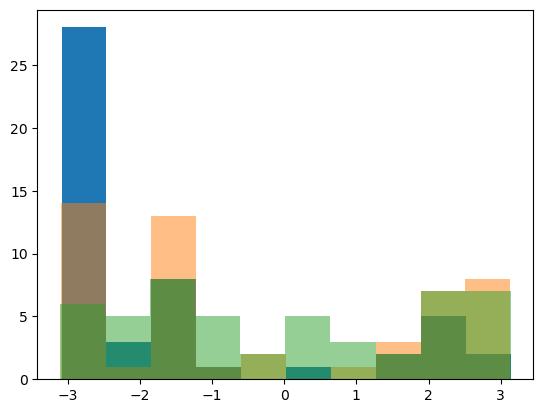

In [371]:
idx =200_000

plt.hist(mu_s1_phi[idx])
plt.hist(mu_s2_phi[idx], alpha=0.5)
plt.hist(mu_s3_phi[idx], alpha=0.5)

In [383]:
new_path = "ball3stick_new"

In [416]:
import nibabel as nib
from dmri.utils.dmriutils import export_nifti
org_data = nib.load("data/data.nii.gz")

directions_s1 = sph2cart(np.stack([mu_s1_theta, mu_s1_phi], axis=-1))
directions_s2 = sph2cart(np.stack([mu_s2_theta, mu_s2_phi], axis=-1))
directions_s3 = sph2cart(np.stack([mu_s3_theta, mu_s3_phi], axis=-1))

directions_s1.shape
directions_s2.shape
directions_s3.shape

n_samples = 50

full_directions_s1 = np.zeros(full_data_flat.shape[:-1] + (n_samples,3,))
full_directions_s2 = np.zeros(full_data_flat.shape[:-1] + (n_samples,   3,))
full_directions_s3 = np.zeros(full_data_flat.shape[:-1] + (n_samples,3,))

full_directions_s1[brain_mask_flat.astype(np.bool),:] = directions_s1
full_directions_s2[brain_mask_flat.astype(np.bool),:] = directions_s2
full_directions_s3[brain_mask_flat.astype(np.bool),:] = directions_s3

full_directions_s1 = full_directions_s1.reshape(data_norm.shape[:-1] + (n_samples,3,))
full_directions_s2 = full_directions_s2.reshape(data_norm.shape[:-1] + (n_samples,3,))
full_directions_s3 = full_directions_s3.reshape(data_norm.shape[:-1] + (n_samples,3,))

export_nifti(full_directions_s1[...,:,:], org_data, "", f"{new_path}/s1_directions.nii.gz")
export_nifti(full_directions_s2[...,:,:], org_data, "", f"{new_path}/s2_directions.nii.gz")
export_nifti(full_directions_s3[...,:,:], org_data, "", f"{new_path}/s3_directions.nii.gz")


In [385]:
from dmri.utils.dmriutils import make_dyads
from functools import partial

In [386]:
s1_dyads_mean = jax.vmap(partial(make_dyads))(mu_s1_theta, mu_s1_phi)[0]
s1_dyads_disp = jax.vmap(partial(make_dyads))(mu_s1_theta, mu_s1_phi)[1]
s2_dyads_mean = jax.vmap(partial(make_dyads))(mu_s2_theta, mu_s2_phi)[0]
s2_dyads_disp = jax.vmap(partial(make_dyads))(mu_s2_theta, mu_s2_phi)[1]
s3_dyads_mean = jax.vmap(partial(make_dyads))(mu_s3_theta, mu_s3_phi)[0]
s3_dyads_disp = jax.vmap(partial(make_dyads))(mu_s3_theta, mu_s3_phi)[1]


(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)


In [387]:


full_s1_theta_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s1_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s1_theta
full_s1_theta_samples = full_s1_theta_samples.reshape(data_norm.shape[:-1] + (n_samples,))

full_s1_phi_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s1_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s1_phi
full_s1_phi_samples = full_s1_phi_samples.reshape(data_norm.shape[:-1] + (n_samples,))

full_s2_theta_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s2_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s2_theta
full_s2_theta_samples = full_s2_theta_samples.reshape(data_norm.shape[:-1] + (n_samples,))

full_s2_phi_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s2_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s2_phi
full_s2_phi_samples = full_s2_phi_samples.reshape(data_norm.shape[:-1] + (n_samples,))

full_s3_theta_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s3_theta_samples[brain_mask_flat.astype(np.bool),:] = mu_s3_theta
full_s3_theta_samples = full_s3_theta_samples.reshape(data_norm.shape[:-1] + (n_samples,))

full_s3_phi_samples = np.zeros(full_data_flat.shape[:-1] + (n_samples,))
full_s3_phi_samples[brain_mask_flat.astype(np.bool),:] = mu_s3_phi
full_s3_phi_samples = full_s3_phi_samples.reshape(data_norm.shape[:-1] + (n_samples,))


In [406]:
import nibabel as nib
from dmri.utils.dmriutils import export_nifti
org_data = nib.load("data/data.nii.gz")

export_nifti(full_s1_theta_samples, org_data, "", f"{new_path}/s1_theta_samples.nii.gz")
export_nifti(full_s1_phi_samples, org_data, "", f"{new_path}/s1_phi_samples.nii.gz")
export_nifti(full_s2_theta_samples, org_data, "", f"{new_path}/s2_theta_samples.nii.gz")
export_nifti(full_s2_phi_samples, org_data, "", f"{new_path}/s2_phi_samples.nii.gz")
export_nifti(full_s3_theta_samples, org_data, "", f"{new_path}/s3_theta_samples.nii.gz")
export_nifti(full_s3_phi_samples, org_data, "", f"{new_path}/s3_phi_samples.nii.gz")


In [408]:
full_s1_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s1_dyads_mean[brain_mask_flat.astype(np.bool),:] = s1_dyads_mean
full_s1_dyads_mean = full_s1_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s1_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s1_dyads_disp[brain_mask_flat.astype(np.bool),:] = s1_dyads_disp[...,None]
full_s1_dyads_disp = full_s1_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

export_nifti(full_s1_dyads_mean, org_data, "", f"{new_path}/s1_dyads_mean.nii.gz")
export_nifti(full_s1_dyads_disp, org_data, "", f"{new_path}/s1_dyads_disp.nii.gz")


In [409]:
full_s2_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s2_dyads_mean[brain_mask_flat.astype(np.bool),:] = s2_dyads_mean
full_s2_dyads_mean = full_s2_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s2_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s2_dyads_disp[brain_mask_flat.astype(np.bool),:] = s2_dyads_disp[...,None]
full_s2_dyads_disp = full_s2_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

export_nifti(full_s2_dyads_mean, org_data, "", f"{new_path}/s2_dyads_mean.nii.gz")
export_nifti(full_s2_dyads_disp, org_data, "", f"{new_path}/s2_dyads_disp.nii.gz")


In [410]:
full_s3_dyads_mean = np.zeros(full_data_flat.shape[:-1] + (3,))
full_s3_dyads_mean[brain_mask_flat.astype(np.bool),:] = s3_dyads_mean
full_s3_dyads_mean = full_s3_dyads_mean.reshape(data_norm.shape[:-1] + (3,))

full_s3_dyads_disp = np.zeros(full_data_flat.shape[:-1] + (1,))
full_s3_dyads_disp[brain_mask_flat.astype(np.bool),:] = s3_dyads_disp[...,None]
full_s3_dyads_disp = full_s3_dyads_disp.reshape(data_norm.shape[:-1] + (1,))

export_nifti(full_s3_dyads_mean, org_data, "", f"{new_path}/s3_dyads_mean.nii.gz")
export_nifti(full_s3_dyads_disp, org_data, "", f"{new_path}/s3_dyads_disp.nii.gz")


(np.float64(-0.5), np.float64(103.5), np.float64(103.5), np.float64(-0.5))

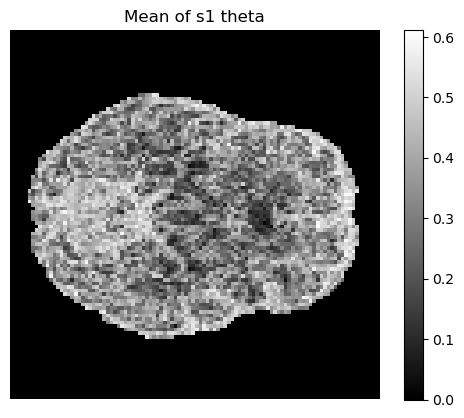

In [415]:
plt.imshow(((full_fractions_mean[...,28:29,0] > 0.05) * full_s1_dyads_disp[...,28:29,0]).reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.title("Mean of s1 theta")
plt.axis("off")

In [393]:
full_f1_mean = full_fractions_mean[...,0]
full_f1_std = full_fractions_std[...,0]
full_f2_mean = full_fractions_mean[...,1]
full_f2_std = full_fractions_std[...,1]
full_f3_mean = full_fractions_mean[...,2]
full_f3_std = full_fractions_std[...,2]
full_f4_mean = full_fractions_mean[...,3]
full_f4_std = full_fractions_std[...,3]
full_diff_mean = full_diffusivities_mean[...,0]
full_diff_std = full_diffusivities_std[...,0]


In [395]:
from dmri.utils.dmriutils import export_nifti
import nibabel as nib
org_data = nib.load("data/data.nii.gz")
export_nifti(full_f1_mean, org_data, "", f"{new_path}/f0_fraction_mean.nii.gz")
export_nifti(full_f1_std, org_data, "", f"{new_path}/f0_fraction_std.nii.gz")
export_nifti(full_f2_mean, org_data, "", f"{new_path}/f1_fraction_mean.nii.gz")
export_nifti(full_f2_std, org_data, "", f"{new_path}/f1_fraction_std.nii.gz")
export_nifti(full_f3_mean, org_data, "", f"{new_path}/f2_fraction_mean.nii.gz")
export_nifti(full_f3_std, org_data, "", f"{new_path}/f2_fraction_std.nii.gz")
export_nifti(full_f4_mean, org_data, "", f"{new_path}/f3_fraction_mean.nii.gz")
export_nifti(full_f4_std, org_data, "", f"{new_path}/f3_fraction_std.nii.gz")
export_nifti(full_diff_mean, org_data, "", f"{new_path}/diff_mean.nii.gz")
export_nifti(full_diff_std, org_data, "", f"{new_path}/diff_std.nii.gz")

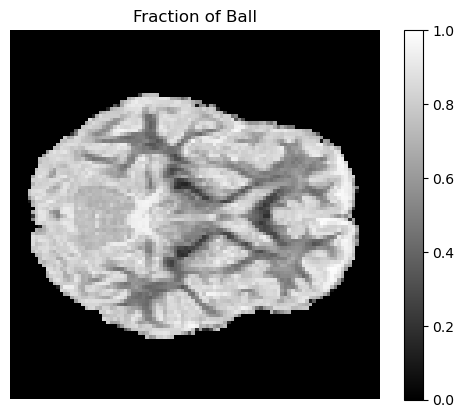

In [412]:
plt.imshow(brain_mask_slice * full_fractions_mean[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Fraction of Ball")
plt.colorbar()


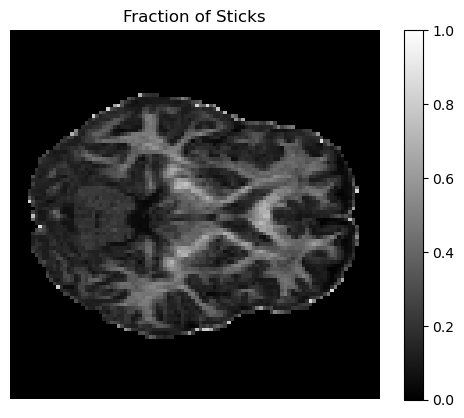

In [413]:
plt.imshow(brain_mask_slice * full_fractions_mean[...,28:29,1:3].sum(axis=-1).reshape(x_o.shape[:-1]), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Fraction of Sticks")
plt.colorbar()

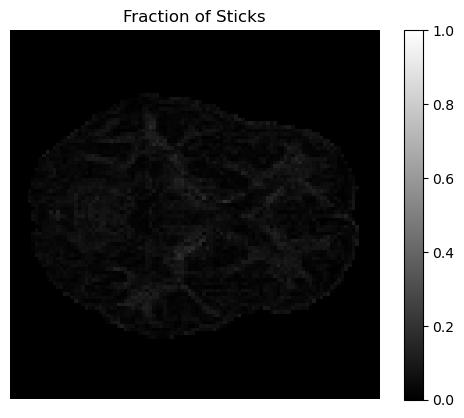

In [414]:
plt.imshow(brain_mask_slice * full_fractions_mean[...,28:29,3].sum(axis=-1).reshape(x_o.shape[:-1]), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Fraction of Sticks")
plt.colorbar()

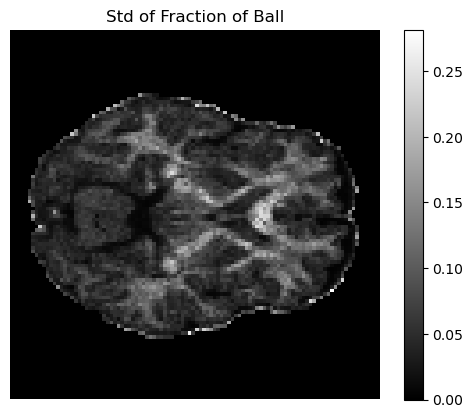

In [403]:
plt.imshow(brain_mask_slice * full_fractions_std[...,28:29,2].reshape(x_o.shape[:-1]), cmap="gray")
plt.axis("off")
plt.title("Std of Fraction of Ball")
plt.colorbar()

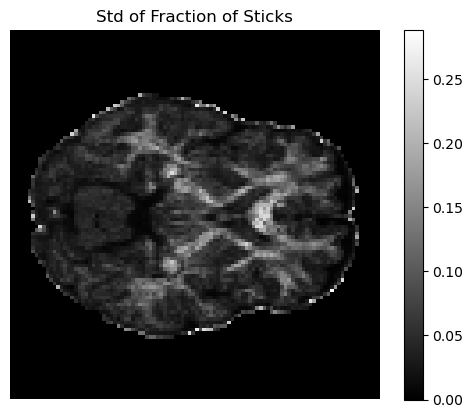

In [404]:
plt.imshow(brain_mask_slice * full_fractions_std[...,28:29,1:3].mean(axis=-1).reshape(x_o.shape[:-1]), cmap="gray")
plt.axis("off")
plt.title("Std of Fraction of Sticks")
plt.colorbar()

Text(0.5, 1.0, 'Mean of Diffusivity')

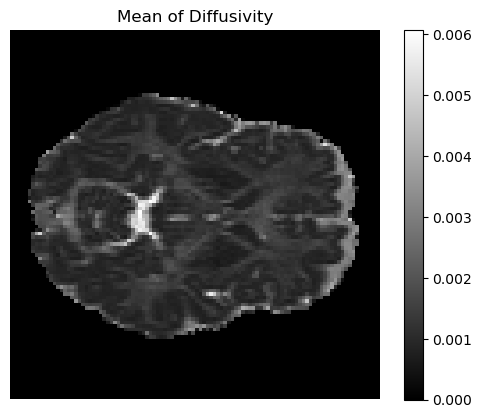

In [56]:
plt.imshow(brain_mask_slice * full_diffusivities_mean[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.axis("off")
plt.title("Mean of Diffusivity")

Text(0.5, 1.0, 'Std of Diffusivity')

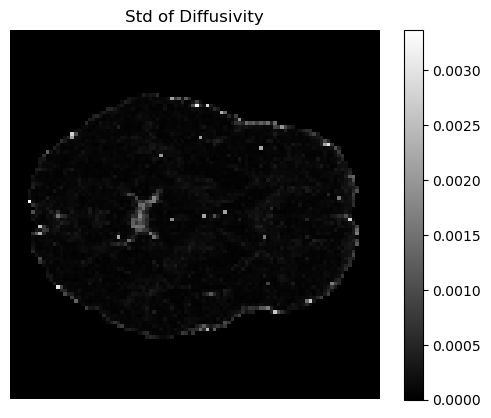

In [57]:
plt.imshow(brain_mask_slice * full_diffusivities_std[...,28:29,0].reshape(x_o.shape[:-1]), cmap="gray")
plt.colorbar()
plt.axis("off")
plt.title("Std of Diffusivity")


In [393]:
x_o_flat.shape

(10816, 105)

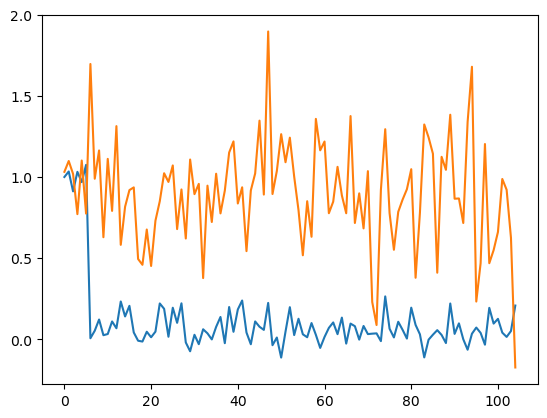